
# Experiment results analysis

This notebook loads the final CSV summaries produced by the existing notebooks so that we can analyze them.


In [1]:
from src.result_analysis_plots import *

# You can keep exact file names or patterns with * ("top_side_frozen_lovo_*.csv") to automatically pick the latest matching file
RESULT_FILE_SPECS = {
    "top_side_performance": "top_side_frozen_performance_FINAL.csv",
    "only_top_performance": "only_top_frozen_performance_FINAL.csv",
    "only_side_performance": "only_side_frozen_performance_FINAL.csv",
    "top_side_lovo": "top_side_frozen_lovo_FINAL.csv",
}

OOF_FILE_SPECS = {
    "top_side_performance": "top_side_frozen_performance_oof_predictions_FINAL.csv",
    "only_top_performance": "only_top_frozen_performance_oof_predictions_FINAL.csv",
    "only_side_performance": "only_side_frozen_performance_oof_predictions_FINAL.csv",
    "top_side_lovo": "top_side_frozen_lovo_oof_predictions_FINAL.csv",
}

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

/home/lenka-hake/Documents/CV/ComputerVisionProject/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Load Results

In [2]:
top_side_performance_df = load_result_csv(
    resolve_result_file(RESULT_FILE_SPECS["top_side_performance"], results_dir=OUTPUT_DIR),
    experiment_name="top_side_performance", results_dir=OUTPUT_DIR)

only_top_performance_df = load_result_csv(
    resolve_result_file(RESULT_FILE_SPECS["only_top_performance"], results_dir=OUTPUT_DIR),
    experiment_name="only_top_performance", results_dir=OUTPUT_DIR)

only_side_performance_df = load_result_csv(
    resolve_result_file(RESULT_FILE_SPECS["only_side_performance"], results_dir=OUTPUT_DIR),
    experiment_name="only_side_performance", results_dir=OUTPUT_DIR)

top_side_lovo_df = load_result_csv(
    resolve_result_file(RESULT_FILE_SPECS["top_side_lovo"], results_dir=OUTPUT_DIR),
    experiment_name="top_side_lovo", results_dir=OUTPUT_DIR)

top_side_performance_oof_df = pd.read_csv(resolve_result_file(OOF_FILE_SPECS["top_side_performance"], results_dir=OUTPUT_DIR))
only_top_performance_oof_df = pd.read_csv(resolve_result_file(OOF_FILE_SPECS["only_top_performance"], results_dir=OUTPUT_DIR))
only_side_performance_oof_df = pd.read_csv(resolve_result_file(OOF_FILE_SPECS["only_side_performance"], results_dir=OUTPUT_DIR))
top_side_lovo_oof_df = pd.read_csv(resolve_result_file(OOF_FILE_SPECS["top_side_lovo"], results_dir=OUTPUT_DIR))

resolved_files = {
    "top_side_performance": resolve_result_file(RESULT_FILE_SPECS["top_side_performance"], results_dir=OUTPUT_DIR),
    "only_top_performance": resolve_result_file(RESULT_FILE_SPECS["only_top_performance"], results_dir=OUTPUT_DIR),
    "only_side_performance": resolve_result_file(RESULT_FILE_SPECS["only_side_performance"], results_dir=OUTPUT_DIR),
    "top_side_lovo": resolve_result_file(RESULT_FILE_SPECS["top_side_lovo"], results_dir=OUTPUT_DIR),
}

resolved_oof_files = {
    "top_side_performance": resolve_result_file(OOF_FILE_SPECS["top_side_performance"], results_dir=OUTPUT_DIR),
    "only_top_performance": resolve_result_file(OOF_FILE_SPECS["only_top_performance"], results_dir=OUTPUT_DIR),
    "only_side_performance": resolve_result_file(OOF_FILE_SPECS["only_side_performance"], results_dir=OUTPUT_DIR),
    "top_side_lovo": resolve_result_file(OOF_FILE_SPECS["top_side_lovo"], results_dir=OUTPUT_DIR),
}

print("Resolved files:")
for key, path in resolved_files.items():
    print(f"  {key}: {path}")

print()
print("Resolved OOF files:")
for key, path in resolved_oof_files.items():
    print(f"  {key}: {path}")

print()
print("Shapes:")
print("  top_side_performance_df:", top_side_performance_df.shape)
print("  only_top_performance_df:", only_top_performance_df.shape)
print("  only_side_performance_df:", only_side_performance_df.shape)
print("  top_side_lovo_df:", top_side_lovo_df.shape)
print()
print("OOF shapes:")
print("  top_side_performance_oof_df:", top_side_performance_oof_df.shape)
print("  only_top_performance_oof_df:", only_top_performance_oof_df.shape)
print("  only_side_performance_oof_df:", only_side_performance_oof_df.shape)
print("  top_side_lovo_oof_df:", top_side_lovo_oof_df.shape)

Resolved files:
  top_side_performance: results/top_side_frozen_performance_FINAL.csv
  only_top_performance: results/only_top_frozen_performance_FINAL.csv
  only_side_performance: results/only_side_frozen_performance_FINAL.csv
  top_side_lovo: results/top_side_frozen_lovo_FINAL.csv

Resolved OOF files:
  top_side_performance: results/top_side_frozen_performance_oof_predictions_FINAL.csv
  only_top_performance: results/only_top_frozen_performance_oof_predictions_FINAL.csv
  only_side_performance: results/only_side_frozen_performance_oof_predictions_FINAL.csv
  top_side_lovo: results/top_side_frozen_lovo_oof_predictions_FINAL.csv

Shapes:
  top_side_performance_df: (81, 12)
  only_top_performance_df: (4, 12)
  only_side_performance_df: (4, 12)
  top_side_lovo_df: (6, 12)

OOF shapes:
  top_side_performance_oof_df: (33600, 12)
  only_top_performance_oof_df: (1260, 12)
  only_side_performance_oof_df: (1260, 12)
  top_side_lovo_oof_df: (2520, 12)


# Some Examples using Top-Side + Frozen Feature Extraction

## Top Results

In [3]:
show_top(top_side_performance_df, n=10, metric="cv_mae_mean")

,backbone,fusion,regressor,cv_mae_mean,cv_rmse_mean,cv_r2_mean
0,densenet121,concat,ridge,0.2581,0.3297,0.9215
1,densenet121,concat,linear,0.2657,0.3408,0.9164
2,densenet121,concat,elasticnet,0.2661,0.3386,0.9173
3,densenet121,concat_abs_diff,ridge,0.2672,0.3415,0.9160
4,densenet121,concat_abs_diff,linear,0.2712,0.3453,0.9141
5,densenet121,concat_abs_diff,elasticnet,0.2740,0.3466,0.9133
6,densenet121,mean,ridge,0.2842,0.3637,0.9049
7,densenet121,max,ridge,0.2862,0.3660,0.9043
8,densenet121,max,elasticnet,0.2884,0.3712,0.9001
9,densenet121,mean,elasticnet,0.2912,0.3744,0.8980


## Comparison for Different Backbones, Fusion Methods, and Regressors

,backbone,best_mae,mean_mae,median_mae,best_rmse,mean_rmse,best_r2,mean_r2,top_10_count
0,densenet121,0.2581,0.3685,0.2987,0.3297,0.4668,0.9215,0.8224,10
1,convnext_tiny,0.2964,0.3903,0.3513,0.3748,0.4889,0.9008,0.8183,0
2,resnet50,0.3291,0.4699,0.3464,0.4175,0.5914,0.8759,0.6901,0
3,vit_b_16,0.3330,0.4302,0.3962,0.4229,0.5390,0.8739,0.7811,0
4,dummy_mean,1.0614,1.0614,1.0614,1.1932,1.1932,0.0000,0.0000,0


,fusion,best_mae,mean_mae,median_mae,best_rmse,mean_rmse,best_r2,mean_r2,top_10_count
0,concat,0.2581,0.4195,0.3499,0.3297,0.5293,0.9215,0.7619,3
1,concat_abs_diff,0.2672,0.4168,0.3447,0.3415,0.5245,0.9160,0.7662,3
2,mean,0.2842,0.4050,0.3557,0.3637,0.5076,0.9049,0.7998,2
3,max,0.2862,0.4177,0.3596,0.3660,0.5248,0.9043,0.7841,2
4,dummy_mean,1.0614,1.0614,1.0614,1.1932,1.1932,0.0000,0.0000,0


,regressor,best_mae,mean_mae,median_mae,best_rmse,mean_rmse,best_r2,mean_r2,top_10_count
0,ridge,0.2581,0.3140,0.3245,0.3297,0.3994,0.9215,0.8853,4
1,linear,0.2657,0.3409,0.3405,0.3408,0.4312,0.9164,0.8657,2
2,elasticnet,0.2661,0.3193,0.3328,0.3386,0.4041,0.9173,0.8826,4
3,random_forest,0.3517,0.4069,0.4142,0.4391,0.4999,0.8637,0.8225,0
4,mlp,0.5080,0.6926,0.6420,0.6307,0.8732,0.7196,0.4338,0
5,dummy_mean,1.0614,1.0614,1.0614,1.1932,1.1932,0.0000,0.0000,0


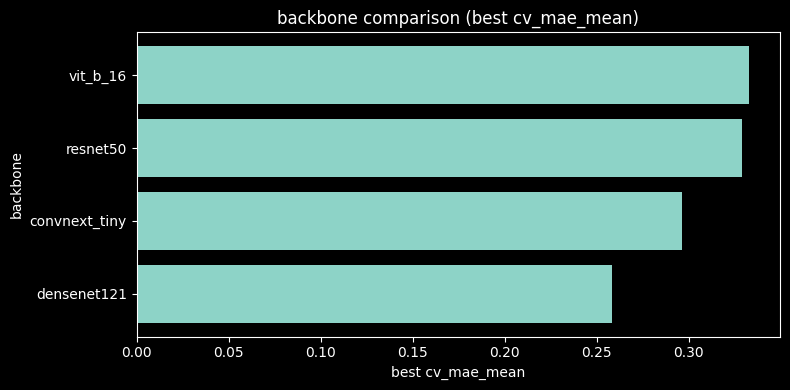

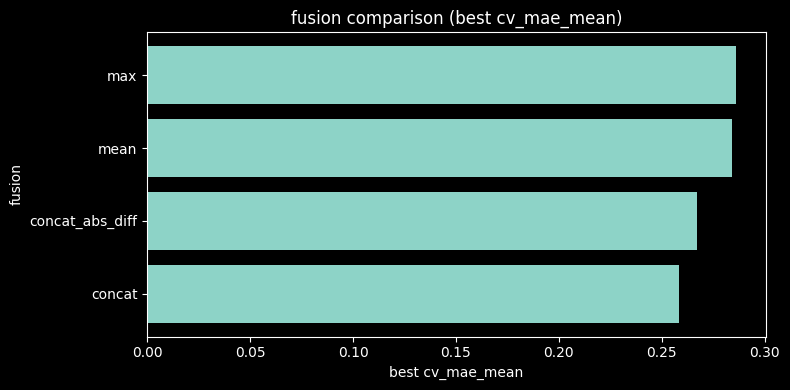

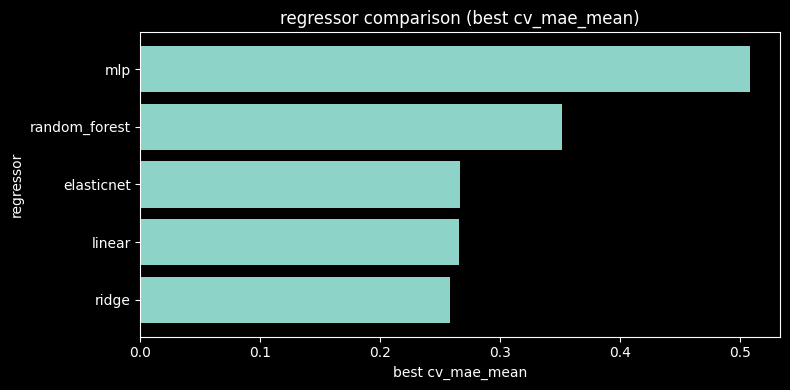

In [4]:
display(summarize_by(top_side_performance_df, "backbone"))
display(summarize_by(top_side_performance_df, "fusion"))
display(summarize_by(top_side_performance_df, "regressor"))

excluding_dummy = top_side_performance_df.head(len(top_side_performance_df) - 1)
plot_group_summary(excluding_dummy, "backbone", metric="cv_mae_mean", agg="best")
plot_group_summary(excluding_dummy, "fusion", metric="cv_mae_mean", agg="best")
plot_group_summary(excluding_dummy, "regressor", metric="cv_mae_mean", agg="best")

## Pairwise Heatmaps

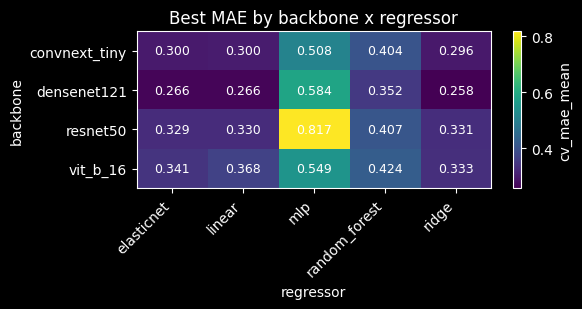

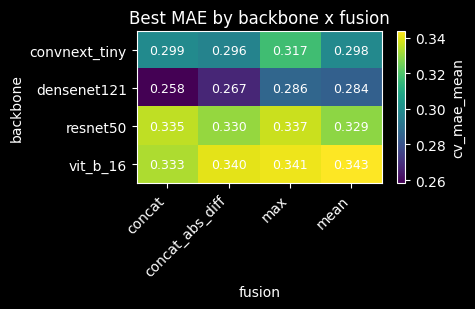

In [5]:
excluding_dummy = top_side_performance_df.head(len(top_side_performance_df) - 1)

plot_pairwise_heatmap(
    filter_results(excluding_dummy),
    row_col="backbone",
    col_col="regressor",
    metric="cv_mae_mean",
    agg="min",
    title="Best MAE by backbone x regressor",
)

plot_pairwise_heatmap(
    filter_results(excluding_dummy),
    row_col="backbone",
    col_col="fusion",
    metric="cv_mae_mean",
    agg="min",
    title="Best MAE by backbone x fusion",
)

## Results for DenseNet121

In [6]:
subset_df = filter_results(
    top_side_performance_df,
    experiments=None,
    backbones=["densenet121"],
    fusions=None,
    regressors=None,
)

show_top(subset_df, n=20, metric="cv_mae_mean")

,backbone,fusion,regressor,cv_mae_mean,cv_rmse_mean,cv_r2_mean
0,densenet121,concat,ridge,0.2581,0.3297,0.9215
1,densenet121,concat,linear,0.2657,0.3408,0.9164
2,densenet121,concat,elasticnet,0.2661,0.3386,0.9173
3,densenet121,concat_abs_diff,ridge,0.2672,0.3415,0.9160
4,densenet121,concat_abs_diff,linear,0.2712,0.3453,0.9141
5,densenet121,concat_abs_diff,elasticnet,0.2740,0.3466,0.9133
6,densenet121,mean,ridge,0.2842,0.3637,0.9049
7,densenet121,max,ridge,0.2862,0.3660,0.9043
8,densenet121,max,elasticnet,0.2884,0.3712,0.9001
9,densenet121,mean,elasticnet,0.2912,0.3744,0.8980


## True vs Predicted Volume Plots for Best Configurations

Experiment: top_side_performance (top 2 models)


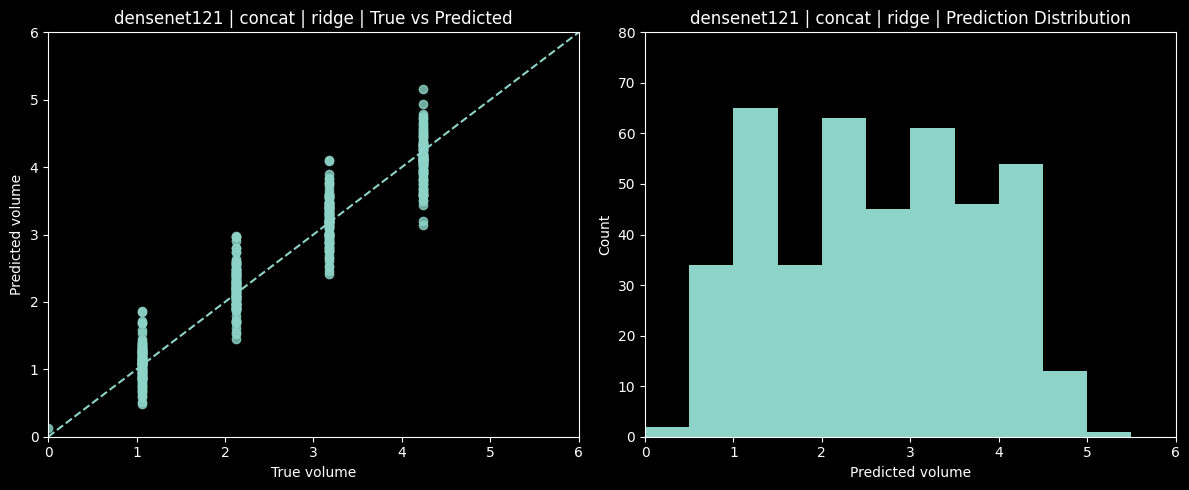

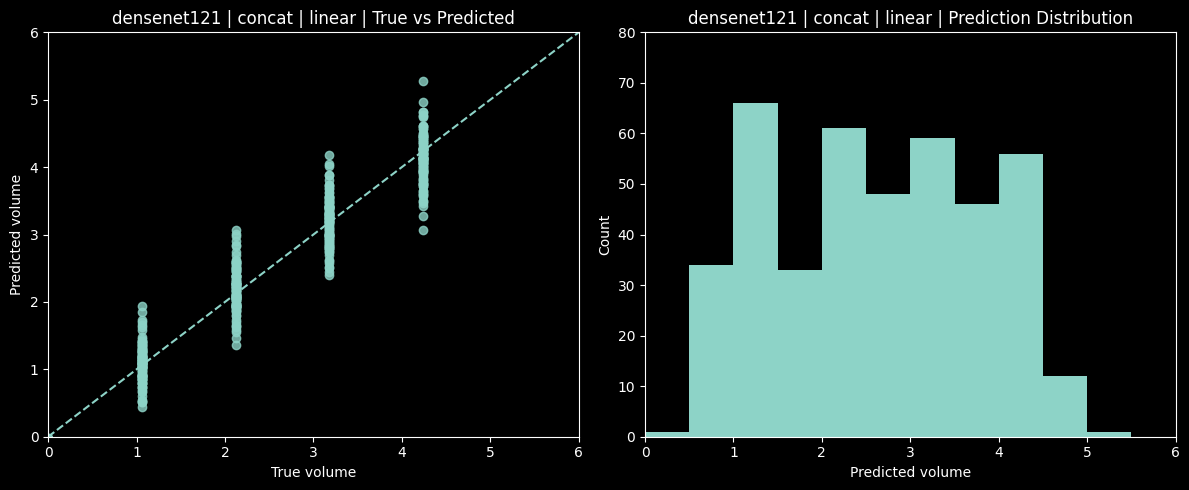

In [8]:
plot_best_oof_predictions(top_side_performance_df, top_side_performance_oof_df, "top_side_performance", top_n=2)